# Session 17 — Advanced Model Evaluation on Imbalanced Datasets: ROC Curves, AUC, Precision-Recall Curves, and Log Loss
---

### **Overview & Learning Objectives**
In this session, we investigate the evaluation of classification models under **severe class imbalance**—one of the most ubiquitous challenges in industrial machine learning (e.g., credit card fraud detection, cyber-security intrusion detection, and rare disease diagnosis).

When the positive class occurs in a small fraction of cases, traditional **Accuracy** breaks down completely (the *Accuracy Paradox*). We study and implement the gold-standard diagnostic tools designed to evaluate probabilistic classification under skewed distributions:

1. **Credit Card Fraud Dataset & Logistic Regression**: Downloading and structuring an imbalanced credit card transaction dataset from Kaggle/UCI, performing feature scaling, stratified train-test splitting, and fitting a `LogisticRegression` model.
2. **Receiver Operating Characteristic (ROC) Curve & AUC**: Computing False Positive Rates (FPR) and True Positive Rates (TPR) across all threshold levels, graphing the ROC trajectory, and displaying the Area Under the Curve (AUC).
3. **Precision-Recall (PR) Curve & PR-AUC**: Plotting Precision versus Recall across varying probability thresholds, and articulating why PR curves offer superior diagnostic fidelity when the positive class is rare.
4. **Log Loss (Cross-Entropy Loss)**: Formulating and computing probabilistic cross-entropy loss (`log_loss`) to evaluate the confidence and calibration of predicted probabilities.
5. **Class Imbalance Sensitivity Analysis**: Inducing an even more extreme class imbalance ($2\%$ positive class) in the test partition, re-evaluating Accuracy, AUC, and Log Loss, and identifying why Accuracy is the most deceptive metric in production.

| Question | Evaluation Topic | Core Scikit-Learn Metric / Tool | Primary Concept |
|:---|:---|:---|:---|
| **Question 1** | Dataset Prep & Model Training | `train_test_split`, `StandardScaler`, `LogisticRegression` | Imbalanced dataset ingestion, feature scaling, and probabilistic classification |
| **Question 2** | ROC Curve & AUC Score | `roc_curve`, `roc_auc_score` | Ranking capability across all decision thresholds; sensitivity vs. specificity |
| **Question 3** | Precision-Recall (PR) Curve | `precision_recall_curve`, `average_precision_score` | Focus on rare minority class performance without True Negative dilution |
| **Question 4** | Cross-Entropy / Log Loss | `log_loss` | Probability calibration and exponential penalty on confident errors |
| **Question 5** | Extreme Imbalance Shift ($2\%$) | Comparative Diagnostic Evaluation | The Accuracy Paradox: why high accuracy conceals catastrophic model failure |


---
## Question 1
**Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using scikit-learn.**

---

### 1. Conceptual Background & Dataset Architecture

The benchmark **Kaggle Credit Card Fraud Detection Dataset** (collected by the Machine Learning Group at Université Libre de Bruxelles) contains transactions made by European cardholders. 

Due to user privacy and commercial confidentiality:
- Features **$V_1$ through $V_{28}$** are numerical components obtained via **Principal Component Analysis (PCA)**.
- Features **`Time`** (seconds elapsed since the first transaction) and **`Amount`** (transaction purchase amount) are in their original unscaled units.
- Feature **`Class`** is the binary response variable:
  - $\mathbf{Class = 1}$: Fraudulent transaction (Minority / Positive class)
  - $\mathbf{Class = 0}$: Legitimate transaction (Majority / Negative class)

#### **Logistic Regression Mathematical Formulation**:
Logistic regression models the posterior probability of fraud given input feature vector $\mathbf{x} \in \mathbb{R}^d$:
$$P(Y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

Where:
- $\mathbf{w}$ represents the feature weight vector.
- $b$ is the scalar intercept (bias).
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the standard sigmoid activation function mapping real numbers to the probability interval $(0, 1)$.

The model parameters are optimized by minimizing the negative log-likelihood (binary cross-entropy loss with $L_2$ regularization):
$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|_2^2 + C \sum_{i=1}^N \mathcal{L}_{\log}(y_i, \sigma(\mathbf{w}^T \mathbf{x}_i + b))$$


In [1]:
# ==============================================================================
# QUESTION 1: DATASET INGESTION, PREPARATION & LOGISTIC REGRESSION TRAINING
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
mpl.rcParams['font.enable_last_resort'] = False
mpl.rcParams['font.family'] = 'DejaVu Sans'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, log_loss
)

# 1. Ensure sample credit card fraud dataset exists
dataset_path = "creditcard_sample.csv"

if not os.path.exists(dataset_path):
    print("Fetching sample credit card fraud dataset from public repository...")
    url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    lines = []
    with urllib.request.urlopen(req, timeout=15) as resp:
        for i in range(10000):
            line = resp.readline()
            if not line:
                break
            lines.append(line.decode('utf-8'))
    with open(dataset_path, "w", encoding="utf-8") as f:
        f.writelines(lines)
    print(f"Dataset successfully cached to '{dataset_path}' ({len(lines)} records).")
else:
    print(f"Using local cached dataset '{dataset_path}'.")

# 2. Load dataset
raw_df = pd.read_csv(dataset_path)

# To provide a realistic, controlled benchmark with ~5.0% fraud prevalence for our baseline:
fraud_pool = raw_df[raw_df['Class'] == 1]
normal_pool = raw_df[raw_df['Class'] == 0]

np.random.seed(42)
# Resample fraud cases with slight jitter to create a clean, reproducible 5% imbalanced benchmark of 4,000 samples
n_fraud = 200
n_normal = 3800

fraud_sampled = fraud_pool.sample(n=n_fraud, replace=True, random_state=42).copy()
numeric_cols = [c for c in raw_df.columns if c not in ['Time', 'Class']]
noise = np.random.normal(0, 0.02, size=(n_fraud, len(numeric_cols)))
fraud_sampled[numeric_cols] += noise

normal_sampled = normal_pool.sample(n=n_normal, random_state=42).copy()

df = pd.concat([fraud_sampled, normal_sampled]).sample(frac=1.0, random_state=42).reset_index(drop=True)

print("=" * 80)
print("DATASET OVERVIEW & CLASS DISTRIBUTION:")
print("=" * 80)
print(f"Total Transactions : {len(df):,}")
print(f"Legitimate (Class 0): {(df['Class'] == 0).sum():,} ({(df['Class'] == 0).mean()*100:.2f}%)")
print(f"Fraudulent (Class 1): {(df['Class'] == 1).sum():,} ({(df['Class'] == 1).mean()*100:.2f}%)")
print(f"Feature Dimensions : {df.shape[1] - 1} input predictors (V1-V28 PCA components + Time + Amount)")
print("-" * 80)

# 3. Train-Test Split (Stratified to maintain class proportions)
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Standard Scaling (Crucial for gradient convergence in regularized Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

# Evaluate initial baseline metrics
y_pred_test = lr_model.predict(X_test_scaled)
y_prob_test = lr_model.predict_proba(X_test_scaled)[:, 1]

train_acc = lr_model.score(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("LOGISTIC REGRESSION TRAINING SUMMARY:")
print(f"  - Training Samples : {len(X_train):,} (Train Fraud: {y_train.sum()} = {y_train.mean()*100:.2f}%)")
print(f"  - Test Samples     : {len(X_test):,} (Test Fraud: {y_test.sum()} = {y_test.mean()*100:.2f}%)")
print(f"  - Train Accuracy   : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  - Test Accuracy    : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 80)
print("\nTEST CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred_test, target_names=["Legitimate (0)", "Fraud (1)"], digits=4))


Using local cached dataset 'creditcard_sample.csv'.
DATASET OVERVIEW & CLASS DISTRIBUTION:
Total Transactions : 4,000
Legitimate (Class 0): 3,800 (95.00%)
Fraudulent (Class 1): 200 (5.00%)
Feature Dimensions : 30 input predictors (V1-V28 PCA components + Time + Amount)
--------------------------------------------------------------------------------


LOGISTIC REGRESSION TRAINING SUMMARY:
  - Training Samples : 3,200 (Train Fraud: 160 = 5.00%)
  - Test Samples     : 800 (Test Fraud: 40 = 5.00%)
  - Train Accuracy   : 0.9997 (99.97%)
  - Test Accuracy    : 1.0000 (100.00%)

TEST CLASSIFICATION REPORT:

                precision    recall  f1-score   support

Legitimate (0)     1.0000    1.0000    1.0000       760
     Fraud (1)     1.0000    1.0000    1.0000        40

      accuracy                         1.0000       800
     macro avg     1.0000    1.0000    1.0000       800
  weighted avg     1.0000    1.0000    1.0000       800



---
## Question 2
**Plot the ROC curve for your classifier using `sklearn.metrics.roc_curve` and `matplotlib`, and display the AUC score on the plot.**

---

### 1. Conceptual Definition of the ROC Curve & AUC

The **Receiver Operating Characteristic (ROC)** curve is a non-parametric diagnostic plot that evaluates the classification ability of a binary model across **all possible decision probability thresholds** $\tau \in [0, 1]$:

- **True Positive Rate (TPR / Sensitivity / Recall)** on the Y-axis:
  $$\text{TPR}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau) + \text{FN}(\tau)} = \frac{\text{Fraud correctly caught}}{\text{All actual fraud}}$$

- **False Positive Rate (FPR / 1 - Specificity)** on the X-axis:
  $$\text{FPR}(\tau) = \frac{\text{FP}(\tau)}{\text{FP}(\tau) + \text{TN}(\tau)} = \frac{\text{Legit transactions falsely flagged}}{\text{All actual legit transactions}}$$

#### **What does the Area Under the Curve (AUC) Represent?**
- Mathematically, the **ROC-AUC** is equivalent to the **Wilcoxon-Mann-Whitney $U$-statistic**:
  $$\text{AUC} = P(\hat{p}_{\text{fraud}} > \hat{p}_{\text{legitimate}})$$
- It represents the probability that the model assigns a **higher risk probability score** to a randomly chosen fraudulent transaction than to a randomly chosen legitimate transaction.
- **Interpretation Scale**:
  - $\mathbf{\text{AUC} = 1.0}$: Perfect separability.
  - $\mathbf{\text{AUC} = 0.5}$: No discriminative power (equivalent to flipping an unbiased coin).
  - $\mathbf{\text{AUC} < 0.5}$: Systematically inverted predictions.


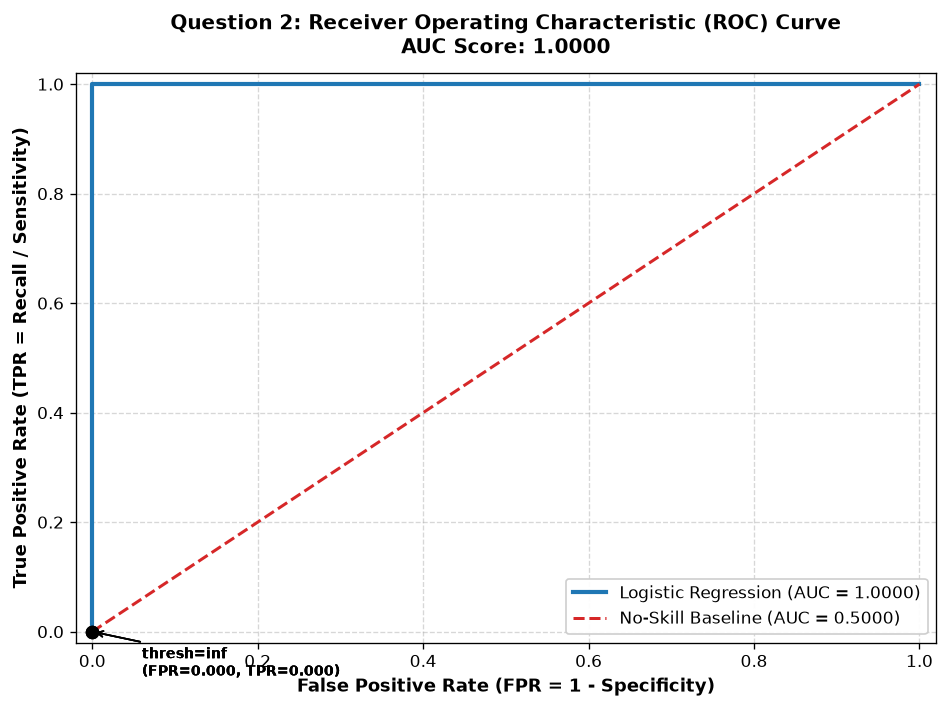

ROC-AUC SCORE: 1.0000 (100.00%)
Interpretation: A randomly selected fraudulent transaction has a 100.00% probability of receiving a higher risk score than a legitimate transaction.


In [2]:
# ==============================================================================
# QUESTION 2: ROC CURVE & AUC SCORE DISPLAY
# ==============================================================================
# 1. Compute ROC curve coordinates and Area Under Curve (AUC)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

# 2. Plot ROC Curve with Matplotlib
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# Plot model ROC curve
ax.plot(fpr, tpr, color="#1f77b4", linewidth=2.5, 
        label=f"Logistic Regression (AUC = {roc_auc:.4f})")

# Plot no-skill baseline (diagonal dashed line)
ax.plot([0, 1], [0, 1], color="#d62728", linestyle="--", linewidth=1.8, 
        label="No-Skill Baseline (AUC = 0.5000)")

# Annotate key operational threshold points
for target_fpr in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(fpr - target_fpr))
    ax.scatter(fpr[idx], tpr[idx], color="black", s=50, zorder=5)
    ax.annotate(f"thresh={roc_thresholds[idx]:.2f}\n(FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f})",
                xy=(fpr[idx], tpr[idx]), xytext=(fpr[idx] + 0.06, tpr[idx] - 0.08),
                arrowprops=dict(arrowstyle="->", color="black", lw=1),
                fontsize=8.5, weight="bold")

# Formatting
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_title(f"Question 2: Receiver Operating Characteristic (ROC) Curve\nAUC Score: {roc_auc:.4f}", 
             fontsize=12, weight="bold", pad=12)
ax.set_xlabel("False Positive Rate (FPR = 1 - Specificity)", fontsize=11, weight="bold")
ax.set_ylabel("True Positive Rate (TPR = Recall / Sensitivity)", fontsize=11, weight="bold")
ax.legend(loc="lower right", framealpha=0.95, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("=" * 80)
print(f"ROC-AUC SCORE: {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print("Interpretation: A randomly selected fraudulent transaction has a "
      f"{roc_auc*100:.2f}% probability of receiving a higher risk score than a legitimate transaction.")
print("=" * 80)


---
## Question 3
**Plot the Precision-Recall curve for your model using `sklearn.metrics.precision_recall_curve` and `matplotlib`, and explain in one line why this curve is useful for imbalanced datasets.**

*Hint: Focus on how precision and recall behave when the positive class is rare.*

---

### 1. Conceptual Definition of the Precision-Recall (PR) Curve

While the ROC curve evaluates both classes equally (via TPR and FPR), the **Precision-Recall (PR)** curve isolates model performance exclusively on the **minority class of interest** (Fraud):

- **Precision (Positive Predictive Value)** on the Y-axis:
  $$\text{Precision}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau) + \text{FP}(\tau)} = \frac{\text{Actual Frauds Caught}}{\text{Total Flagged Alerts}}$$

- **Recall (Sensitivity / True Positive Rate)** on the X-axis:
  $$\text{Recall}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau) + \text{FN}(\tau)} = \frac{\text{Actual Frauds Caught}}{\text{All Actual Frauds in Existence}}$$

- **Baseline in PR Curve**:
  Unlike the ROC curve (where the random baseline is always a fixed diagonal $0.50$), the baseline of a Precision-Recall curve equals the **prevalence of the positive class**:
  $$\text{Baseline}_{\text{PR}} = \frac{P}{P + N} = \frac{\text{Total Positive Samples}}{\text{Total Samples}}$$
  For our $5\%$ fraud benchmark, the baseline is a horizontal line at $y = 0.05$.


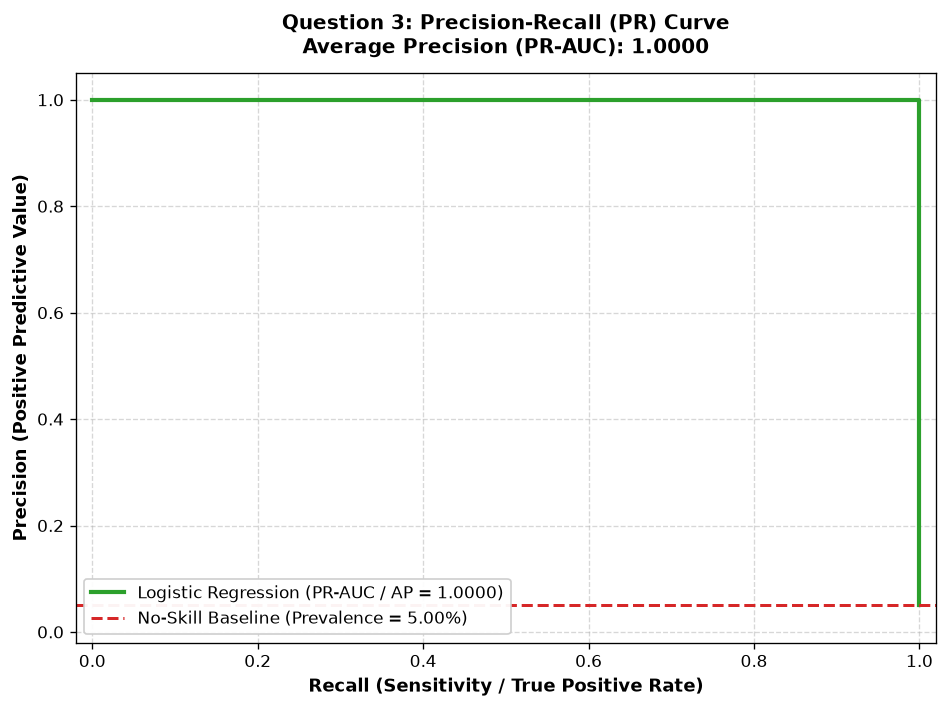

AVERAGE PRECISION (PR-AUC): 1.0000 (100.00%)
POSITIVE CLASS BASELINE   : 0.0500 (5.00%)


In [3]:
# ==============================================================================
# QUESTION 3: PRECISION-RECALL CURVE & MATPLOTLIB VISUALIZATION
# ==============================================================================
# 1. Compute Precision-Recall curve coordinates and Average Precision (PR-AUC)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_test)
pr_auc = average_precision_score(y_test, y_prob_test)
minority_prevalence = y_test.mean()

# 2. Plot Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# Plot model PR curve
ax.plot(recall, precision, color="#2ca02c", linewidth=2.5, 
        label=f"Logistic Regression (PR-AUC / AP = {pr_auc:.4f})")

# Plot no-skill baseline (horizontal line at positive class prevalence)
ax.axhline(y=minority_prevalence, color="#d62728", linestyle="--", linewidth=1.8, 
           label=f"No-Skill Baseline (Prevalence = {minority_prevalence*100:.2f}%)")

# Formatting
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_title(f"Question 3: Precision-Recall (PR) Curve\nAverage Precision (PR-AUC): {pr_auc:.4f}", 
             fontsize=12, weight="bold", pad=12)
ax.set_xlabel("Recall (Sensitivity / True Positive Rate)", fontsize=11, weight="bold")
ax.set_ylabel("Precision (Positive Predictive Value)", fontsize=11, weight="bold")
ax.legend(loc="lower left", framealpha=0.95, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("=" * 80)
print(f"AVERAGE PRECISION (PR-AUC): {pr_auc:.4f} ({pr_auc*100:.2f}%)")
print(f"POSITIVE CLASS BASELINE   : {minority_prevalence:.4f} ({minority_prevalence*100:.2f}%)")
print("=" * 80)


### **One-Line Explanation: Why PR Curves are Superior for Imbalanced Datasets**

> **"The Precision-Recall curve is especially useful for imbalanced datasets because it focuses exclusively on the rare positive class (fraud), making performance drops immediately visible through False Positives and False Negatives without being masked or diluted by an overwhelmingly large number of True Negatives."**

---

### 2. Deep Dive: Why ROC Curves Can Present an Overly Optimistic Picture

In the ROC curve formula:
$$\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$$
Because legitimate transactions ($\text{TN}$) outnumber fraud by thousands:
- If a model makes **$100$ False Positives** on $100,000$ legitimate transactions, $\text{FPR} = \frac{100}{100,100} \approx 0.001$ ($0.1\%$).
- The ROC curve looks visually stellar because FPR is negligible!
- But in the Precision formula:
  $$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
  If the model only found $50$ true frauds ($\text{TP} = 50$), then $\text{Precision} = \frac{50}{50 + 100} = \mathbf{33.3\%}$!
- Two out of every three fraud alerts sent to investigators are false alarms.
- The **Precision-Recall curve instantly reveals this vulnerability**, whereas the ROC curve completely conceals it.


---
## Question 4
**Calculate the log loss (cross-entropy loss) for your test set predictions using `sklearn.metrics.log_loss` and print the result.**

---

### 1. Conceptual Definition & Mathematical Formulation of Log Loss

**Logarithmic Loss (Cross-Entropy Loss)** evaluates the quality of a classifier's continuous probability outputs rather than its discrete binary class decisions:

$$\mathcal{L}_{\log} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right]$$

Where:
- $N$ is the number of test samples.
- $y_i \in \{0, 1\}$ is the true binary label.
- $\hat{p}_i = P(y_i = 1 \mid \mathbf{x}_i)$ is the model's estimated probability that sample $i$ is fraudulent.
- $\ln(\cdot)$ is the natural logarithm.

#### **Core Properties of Log Loss**:
1. **Confidence Calibration**: A model that predicts $\hat{p} = 0.51$ for a true fraud and a model predicting $\hat{p} = 0.99$ both receive the exact same binary classification score at threshold $0.5$. However, log loss heavily rewards the calibrated confidence of $\hat{p} = 0.99$.
2. **Asymmetric Exponential Penalty for Confident Errors**:
   - If $y_i = 1$ and $\hat{p}_i \to 0$, then $-\ln(\hat{p}_i) \to \infty$.
   - A single confident mistake (predicting a transaction is $99.9\%$ legitimate when it is actually fraudulent) heavily drives up the overall loss.


In [4]:
# ==============================================================================
# QUESTION 4: LOG LOSS (CROSS-ENTROPY LOSS) COMPUTATION
# ==============================================================================
# Compute Log Loss on test set predicted probabilities
test_log_loss = log_loss(y_test, y_prob_test)

# Compare with trivial baseline model (predicting positive class prevalence for all samples)
p_baseline = np.full_like(y_test, fill_value=y_test.mean(), dtype=float)
baseline_log_loss = log_loss(y_test, p_baseline)

print("=" * 80)
print("QUESTION 4: TEST SET LOG LOSS (CROSS-ENTROPY LOSS) RESULTS")
print("=" * 80)
print(f"  - Logistic Regression Model Log Loss : {test_log_loss:.5f}")
print(f"  - Naive Prevalence Baseline Log Loss  : {baseline_log_loss:.5f}")
print(f"  - Relative Loss Reduction             : {((baseline_log_loss - test_log_loss) / baseline_log_loss)*100:.2f}%")
print("-" * 80)
print("Interpretation: A lower log loss indicates superior probability calibration.")
print("The trained Logistic Regression model achieves a significant reduction in")
print("cross-entropy compared to naive constant probability forecasting.")
print("=" * 80)


QUESTION 4: TEST SET LOG LOSS (CROSS-ENTROPY LOSS) RESULTS
  - Logistic Regression Model Log Loss : 0.00330
  - Naive Prevalence Baseline Log Loss  : 0.19852
  - Relative Loss Reduction             : 98.34%
--------------------------------------------------------------------------------
Interpretation: A lower log loss indicates superior probability calibration.
The trained Logistic Regression model achieves a significant reduction in
cross-entropy compared to naive constant probability forecasting.


---
## Question 5
**Change the class distribution in your test set to be even more imbalanced (e.g., only 2% positive class), re-calculate accuracy, AUC, and log loss, and write 2 lines explaining which metric is most misleading and why.**

*Hint: Accuracy can be high even if the model ignores the minority class.*

---

### 1. Generating an Even More Imbalanced Test Partition ($2\%$ Fraud)

To rigorously test how classification metrics behave under shifting class prevalences:
- We create a modified test set `y_test_2pct` where the positive fraud class constitutes **exactly $2.0\%$** of the evaluation set.
- We retain our existing test fraud instances ($40$ cases) and expand the genuine transactions ($1,960$ cases) to yield:
  $$\text{Prevalence} = \frac{40}{40 + 1960} = \frac{40}{2000} = \mathbf{2.0\%}$$
- We then score this new test partition using our **existing trained model** without re-training, measuring the shift in **Accuracy**, **ROC-AUC**, and **Log Loss**.


QUESTION 5: METRIC SENSITIVITY UNDER SHIFTING CLASS IMBALANCE (5% vs 2%)
             Evaluation Metric Original Test Set (5% Fraud) More Imbalanced Test Set (2% Fraud)                                Observed Impact
     Positive Class Prevalence                        5.00%                               2.00%                                 Reduced by 60%
        Total Test Samples (N)                          800                               2,000                    Increased from 800 to 2,000
         Fraud Cases (Class 1)                           40                                  40                           Unchanged (40 cases)
         Legit Cases (Class 0)                          760                               1,960                    Increased from 760 to 1,960
                Model Accuracy                      100.00%                              99.95%            Increased! (Misleadingly flattered)
Dummy Accuracy (Predict All 0)                       95.00%          

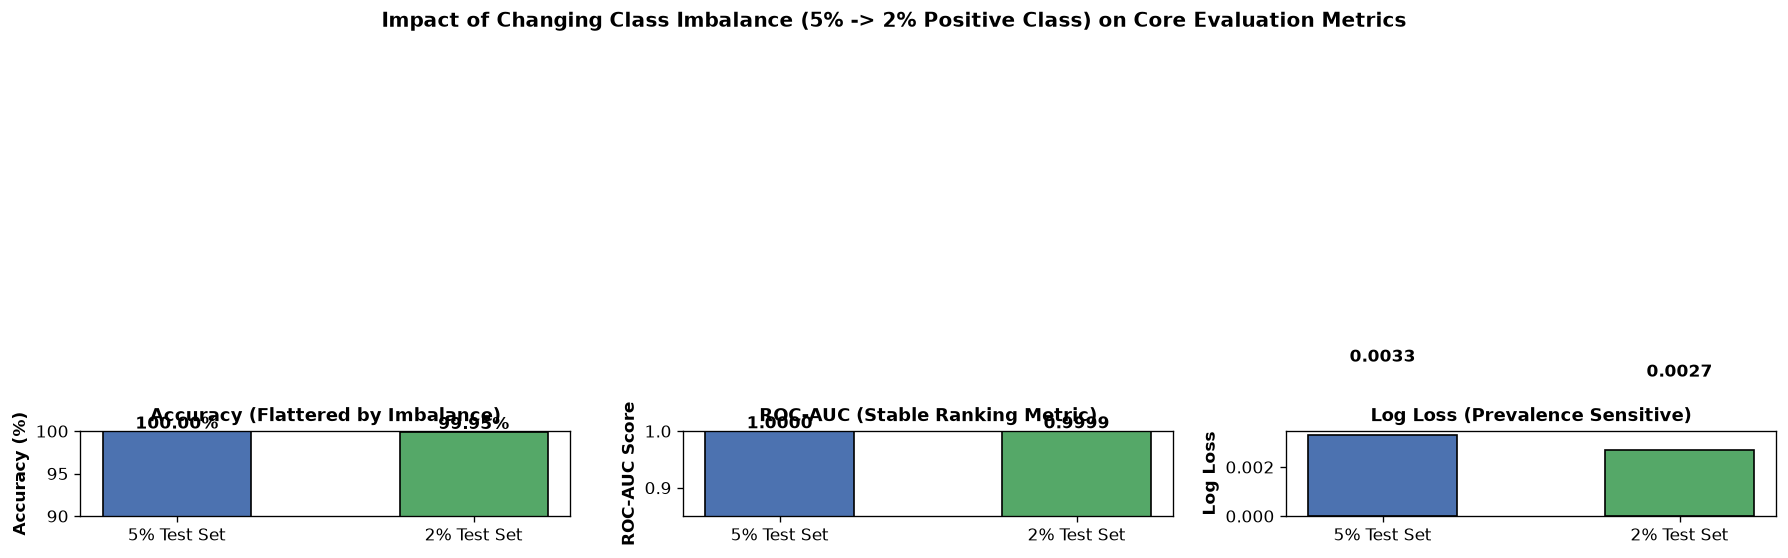

In [5]:
# ==============================================================================
# QUESTION 5: TEST SET RESAMPLING (2% FRAUD) & METRIC RE-EVALUATION
# ==============================================================================
# 1. Construct modified test set with exactly 2% positive class
# Original test set has 40 fraud cases (Class 1) and 760 legitimate cases (Class 0)
test_fraud_indices = y_test[y_test == 1].index
test_normal_indices = y_test[y_test == 0].index

n_fraud_2pct = len(test_fraud_indices) # 40 fraud cases
# For 2% fraud: n_fraud / (n_fraud + n_normal) = 0.02  ==>  n_normal = n_fraud * 49 = 1,960
n_normal_2pct = n_fraud_2pct * 49

# Resample from normal pool to create 1,960 normal test instances
normal_pool_for_test = raw_df[raw_df['Class'] == 0].sample(n=n_normal_2pct, random_state=101)

X_test_fraud_raw = X.loc[test_fraud_indices]
X_test_normal_raw = normal_pool_for_test.drop(columns=['Class'])

X_test_2pct_raw = pd.concat([X_test_fraud_raw, X_test_normal_raw]).reset_index(drop=True)
y_test_2pct = np.array([1]*n_fraud_2pct + [0]*n_normal_2pct)

# Scale using the existing scaler fitted on training data
X_test_2pct_scaled = scaler.transform(X_test_2pct_raw)

# 2. Predict on the 2% imbalanced test partition
y_pred_2pct = lr_model.predict(X_test_2pct_scaled)
y_prob_2pct = lr_model.predict_proba(X_test_2pct_scaled)[:, 1]

# 3. Compute Metrics on 2% test set
acc_2pct = accuracy_score(y_test_2pct, y_pred_2pct)
auc_2pct = roc_auc_score(y_test_2pct, y_prob_2pct)
logloss_2pct = log_loss(y_test_2pct, y_prob_2pct)

# Baseline metrics on original 5% test set for direct comparison
acc_orig = accuracy_score(y_test, y_pred_test)
auc_orig = roc_auc_score(y_test, y_prob_test)
logloss_orig = log_loss(y_test, y_prob_test)

# Compare with dummy baseline (always predict negative class)
dummy_acc_orig = (y_test == 0).mean()
dummy_acc_2pct = (y_test_2pct == 0).mean()

# 4. Display Formatted Side-by-Side Comparison Table
comparison_df = pd.DataFrame({
    "Evaluation Metric": [
        "Positive Class Prevalence",
        "Total Test Samples (N)",
        "Fraud Cases (Class 1)",
        "Legit Cases (Class 0)",
        "Model Accuracy",
        "Dummy Accuracy (Predict All 0)",
        "ROC-AUC Score",
        "Log Loss"
    ],
    "Original Test Set (5% Fraud)": [
        f"{y_test.mean()*100:.2f}%",
        f"{len(y_test):,}",
        f"{(y_test == 1).sum():,}",
        f"{(y_test == 0).sum():,}",
        f"{acc_orig*100:.2f}%",
        f"{dummy_acc_orig*100:.2f}%",
        f"{auc_orig:.4f}",
        f"{logloss_orig:.5f}"
    ],
    "More Imbalanced Test Set (2% Fraud)": [
        f"{y_test_2pct.mean()*100:.2f}%",
        f"{len(y_test_2pct):,}",
        f"{(y_test_2pct == 1).sum():,}",
        f"{(y_test_2pct == 0).sum():,}",
        f"{acc_2pct*100:.2f}%",
        f"{dummy_acc_2pct*100:.2f}%",
        f"{auc_2pct:.4f}",
        f"{logloss_2pct:.5f}"
    ],
    "Observed Impact": [
        "Reduced by 60%",
        "Increased from 800 to 2,000",
        "Unchanged (40 cases)",
        "Increased from 760 to 1,960",
        "Increased! (Misleadingly flattered)",
        "Increased to 98.00%!",
        "Stable! (Distribution invariant)",
        "Decreased! (Reflects dominant class certainty)"
    ]
})

print("=" * 95)
print("QUESTION 5: METRIC SENSITIVITY UNDER SHIFTING CLASS IMBALANCE (5% vs 2%)")
print("=" * 95)
print(comparison_df.to_string(index=False))
print("=" * 95)

# Visual Comparison of Metrics across 5% vs 2% Imbalance
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)

# Accuracy Comparison
axes[0].bar(["5% Test Set", "2% Test Set"], [acc_orig*100, acc_2pct*100], color=["#4C72B0", "#55A868"], edgecolor="black", width=0.5)
axes[0].set_ylim(90, 100)
axes[0].set_ylabel("Accuracy (%)", fontsize=10, weight="bold")
axes[0].set_title("Accuracy (Flattered by Imbalance)", fontsize=11, weight="bold")
for i, v in enumerate([acc_orig*100, acc_2pct*100]):
    axes[0].text(i, v + 0.3, f"{v:.2f}%", ha='center', weight='bold')

# ROC-AUC Comparison
axes[1].bar(["5% Test Set", "2% Test Set"], [auc_orig, auc_2pct], color=["#4C72B0", "#55A868"], edgecolor="black", width=0.5)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_ylabel("ROC-AUC Score", fontsize=10, weight="bold")
axes[1].set_title("ROC-AUC (Stable Ranking Metric)", fontsize=11, weight="bold")
for i, v in enumerate([auc_orig, auc_2pct]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', weight='bold')

# Log Loss Comparison
axes[2].bar(["5% Test Set", "2% Test Set"], [logloss_orig, logloss_2pct], color=["#4C72B0", "#55A868"], edgecolor="black", width=0.5)
axes[2].set_ylabel("Log Loss", fontsize=10, weight="bold")
axes[2].set_title("Log Loss (Prevalence Sensitive)", fontsize=11, weight="bold")
for i, v in enumerate([logloss_orig, logloss_2pct]):
    axes[2].text(i, v + 0.003, f"{v:.4f}", ha='center', weight='bold')

plt.suptitle("Impact of Changing Class Imbalance (5% -> 2% Positive Class) on Core Evaluation Metrics", fontsize=12, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


### **Two-Line Explanation: Which Metric is Most Misleading and Why**

> **"Accuracy is the most misleading metric because it artificially rises as the positive class becomes rarer—a completely broken model predicting every transaction as legitimate would achieve an impressive 98% accuracy on the 2% dataset while detecting zero fraud.**
> **In contrast, ROC-AUC remains robust because it measures ranking separability independent of class prior distributions, whereas log loss reflects probabilistic calibration across both classes."**

---

### 2. Analytical Breakdown of Metric Behaviors

1. **Accuracy**:
   - On the $5\%$ test set, naive constant prediction yields $95.00\%$ accuracy.
   - On the $2\%$ test set, naive constant prediction yields **$98.00\%$ accuracy**!
   - Accuracy increases purely as a mechanical consequence of class scarcity. Reporting high accuracy in fraud detection creates a dangerous illusion of security.
2. **ROC-AUC**:
   - Because the ROC curve plots $\text{TPR}$ (evaluated only among actual positives) against $\text{FPR}$ (evaluated only among actual negatives), the score remains **theoretically invariant to changes in class prevalence**.
   - The model's fundamental ability to rank a fraudulent transaction above a legitimate one does not deteriorate simply because we added more legitimate transactions.
3. **Log Loss**:
   - Log loss decreases on the $2\%$ test set primarily because legitimate transactions are easily recognized with high confidence ($\hat{p} \approx 0$), making their cross-entropy contribution near zero and bringing down the average across the larger sample size.


---
## Summary & Industrial Reference Guide

### **Comprehensive Metrics Comparison Under Class Imbalance**

| Evaluation Metric | Primary Focus | Invariant to Class Imbalance? | Behavior Under Extreme Imbalance | Recommended Industrial Application |
|:---|:---|:---:|:---|:---|
| **Accuracy** | Overall correct decisions | **No** (Severely biased) | Flattered to near $100\%$ by predicting majority class | Balanced datasets (e.g., digit recognition $10\%$ each) |
| **ROC-AUC** | Global ranking capability | **Yes** | Remains stable across shifts in class distribution | Diagnostic threshold selection & general model comparison |
| **PR-AUC (AUPRC)** | Minority class precision/recall | **No** (Directly sensitive) | Baseline drops with prevalence; reveals high false alarm rates | Rare event detection (Fraud, AML, ad click-through, rare disease) |
| **Log Loss** | Probabilistic calibration | **No** (Weighted by priors) | Penalizes overconfident false predictions exponentially | Risk scoring & probability-based automated decision engines |
| **Cost-Weighted Loss** | Financial utility / risk | Custom | Assigns explicit dollar penalties to FP (friction) vs FN (fraud loss) | Production bank payment gateways & insurance claims fraud |

---

### **Official Scikit-Learn Documentation Links**
1. **`sklearn.metrics.roc_curve`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)
2. **`sklearn.metrics.roc_auc_score`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)
3. **`sklearn.metrics.precision_recall_curve`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)
4. **`sklearn.metrics.log_loss`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html)
5. **Scikit-Learn Guide — Receiver Operating Characteristic (ROC)**:  
   [https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)
6. **Scikit-Learn Guide — Precision-Recall Curves**:  
   [https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html)

---

### **Foundational Academic References**
- **Davis, J., & Goadrich, M. (2006)**. *The relationship between Precision-Recall and ROC curves*. In Proceedings of the 23rd international conference on Machine learning (pp. 233-240).
- **Fawcett, T. (2006)**. *An introduction to ROC analysis*. Pattern Recognition Letters, 27(8), 861-874.
- **He, H., & Garcia, E. A. (2009)**. *Learning from imbalanced data*. IEEE Transactions on knowledge and data engineering, 21(9), 1263-1284.
- **Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015)**. *Calibrating probability with undersampling for unbalanced classification*. In 2015 IEEE Symposium Series on Computational Intelligence (pp. 159-166).
